# Results Tables: Table 2 & Table 3

Quantitative results reported in the manuscript:
- **Table 2**: Fold-wise segmentation (Dice, IoU) — SegFormer, Mask R-CNN, YOLOv8-Seg
- **Table 3**: Fold-wise classification (Accuracy, Sensitivity, Specificity, F1-score)

**Manuscript reference:** Table 2, Table 3

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, mannwhitneyu
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve, auc, 
                              brier_score_loss, accuracy_score, f1_score, recall_score, 
                              precision_score, cohen_kappa_score)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Plotting setup
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

# Paths
OUTPUT_BASE = 'folds/folds/output'
FIG_DIR = 'q1_publication_results'
os.makedirs(FIG_DIR, exist_ok=True)
for subdir in ['figures', 'tables', 'supplementary']:
    os.makedirs(os.path.join(FIG_DIR, subdir), exist_ok=True)

print("✓ Setup complete!")

✓ Setup complete!


In [2]:
# Load summary
summary_df = pd.read_csv(os.path.join(OUTPUT_BASE, 'all_folds_runs_summary.csv'))
print(f"Total runs: {len(summary_df)}")
print(f"Unique folds: {summary_df['fold'].nunique()}")
print(f"Runs per fold: {summary_df.groupby('fold').size().tolist()}")

summary_df.head()

Total runs: 50
Unique folds: 5
Runs per fold: [10, 10, 10, 10, 10]


,best_arthrit_boost,best_cls_loss_weight,best_control_boost,best_eval_batch_size,best_focal_gamma,best_lr,best_train_batch_size,best_weight_decay,final_test_loss,final_test_mDice_fg_patient,...,lr_scheduler_type,max_grad_norm,patient_balanced_sampling,pool_alpha,pool_mode,run_idx,search_mean_val_mDice_fg_patient,seed,train_runtime,unfreeze_epoch
0,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.977758,0.827919,...,cosine,1.0,True,1.0,mask,1,0.821892,42,2058.2716,5
1,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.540005,0.823755,...,cosine,1.0,True,1.0,mask,2,0.821892,1042,1128.9786,5
2,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.628001,0.812692,...,cosine,1.0,True,1.0,mask,3,0.821892,2042,1581.7083,5
3,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.315959,0.773808,...,cosine,1.0,True,1.0,mask,4,0.821892,3042,444.4284,5
4,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.957584,0.833754,...,cosine,1.0,True,1.0,mask,5,0.821892,4042,2646.8509,5


In [3]:
# Load all predictions
def load_all_predictions():
    dfs = []
    for fold_dir in sorted(glob.glob(os.path.join(OUTPUT_BASE, 'FOLD_*'))):
        fold = os.path.basename(fold_dir)
        for run_dir in sorted(glob.glob(os.path.join(fold_dir, 'run_*'))):
            run = os.path.basename(run_dir)
            pred_file = os.path.join(run_dir, 'final/fold_test_predictions/predictions.csv')
            if os.path.exists(pred_file):
                df = pd.read_csv(pred_file)
                df['fold'] = fold
                df['run'] = run
                dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

preds_df = load_all_predictions()
print(f"\nTotal predictions: {len(preds_df)}")
print(f"Unique patients: {preds_df['patient_id'].nunique()}")

preds_df.head()


Total predictions: 6550
Unique patients: 503


,image_path,patient_id,total_pixels,positive_pixels,positive_ratio,true_group,cls_head_class,cls_head_prob,arthrit_prob,fold,run
0,folds/folds/FOLD_1/test/darkened/image_005_R_P...,005_R_P_001,786432,21865,0.027803,arthrit,arthrit,1.0,1.0,FOLD_1,run_1
1,folds/folds/FOLD_1/test/darkened/image_005_R_P...,005_R_P_002,786432,27225,0.034618,arthrit,arthrit,1.0,1.0,FOLD_1,run_1
2,folds/folds/FOLD_1/test/darkened/image_005_R_P...,005_R_P_003,786432,27695,0.035216,arthrit,arthrit,1.0,1.0,FOLD_1,run_1
3,folds/folds/FOLD_1/test/darkened/image_005_R_P...,005_R_P_004,786432,24700,0.031408,arthrit,arthrit,1.0,1.0,FOLD_1,run_1
4,folds/folds/FOLD_1/test/darkened/image_005_R_P...,005_R_P_005,786432,53234,0.067691,arthrit,arthrit,1.0,1.0,FOLD_1,run_1


In [4]:
# Aggregate patient-level predictions
valid_preds = preds_df[preds_df['true_group'].isin(['control', 'arthrit'])].copy()

patient_level = valid_preds.groupby(['fold', 'run', 'patient_id']).agg({
    'true_group': 'first',
    'arthrit_prob': 'mean',
    'positive_ratio': 'mean'
}).reset_index()

patient_level['y_true'] = (patient_level['true_group'] == 'arthrit').astype(int)
patient_level['y_pred'] = (patient_level['arthrit_prob'] >= 0.5).astype(int)

print(f"Patient-level data: {len(patient_level)} patients")
patient_level.head()

Patient-level data: 6550 patients


,fold,run,patient_id,true_group,arthrit_prob,positive_ratio,y_true,y_pred
0,FOLD_1,run_1,005_R_P_001,arthrit,1.0,0.027803,1,1
1,FOLD_1,run_1,005_R_P_002,arthrit,1.0,0.034618,1,1
2,FOLD_1,run_1,005_R_P_003,arthrit,1.0,0.035216,1,1
3,FOLD_1,run_1,005_R_P_004,arthrit,1.0,0.031408,1,1
4,FOLD_1,run_1,005_R_P_005,arthrit,1.0,0.067691,1,1


In [5]:
def bootstrap_ci(data, n_boot=10000, ci=95):
    """Bootstrap confidence interval"""
    boot_means = []
    for i in range(n_boot):
        boot_sample = resample(data, replace=True, random_state=i)
        boot_means.append(np.mean(boot_sample))
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return lower, upper

# Calculate metrics
metrics_config = {
    'Test mDice (%)': 'final_test_mDice_fg_patient',
    'Val mDice (%)': 'final_val_mDice_fg_patient',
    'Val Accuracy (%)': 'final_val_cls_acc_patient',
    'Val F1-Score (%)': 'final_val_cls_f1_patient',
    'Val ROC-AUC (%)': 'final_val_cls_roc_auc_patient',
    'Val PR-AUC (%)': 'final_val_cls_pr_auc_patient'
}

results = []
for name, col in metrics_config.items():
    if col in summary_df.columns:
        values = summary_df[col].dropna().values * 100
        mean = np.mean(values)
        std = np.std(values, ddof=1)
        ci_low, ci_high = bootstrap_ci(values)
        
        results.append({
            'Metric': name,
            'Mean ± SD': f'{mean:.2f} ± {std:.2f}',
            '95% CI': f'[{ci_low:.2f}, {ci_high:.2f}]',
            'Min': f'{np.min(values):.2f}',
            'Max': f'{np.max(values):.2f}'
        })

main_results = pd.DataFrame(results)
print("\n" + "="*80)
print("MAIN RESULTS TABLE")
print("="*80)
print(main_results.to_string(index=False))
print("="*80)

# Save
main_results.to_csv(os.path.join(FIG_DIR, 'tables/main_results.csv'), index=False)
main_results.to_latex(os.path.join(FIG_DIR, 'tables/main_results.tex'), index=False)

main_results


MAIN RESULTS TABLE
          Metric     Mean ± SD         95% CI   Min    Max
  Test mDice (%)  79.86 ± 6.36 [77.88, 81.39] 46.33  84.46
   Val mDice (%)  81.88 ± 8.02 [79.42, 83.83] 46.88  86.87
Val Accuracy (%)  87.64 ± 9.84 [84.90, 90.24] 61.54 100.00
Val F1-Score (%) 86.54 ± 10.60 [83.59, 89.33] 61.54 100.00
 Val ROC-AUC (%)  96.45 ± 5.05 [95.01, 97.80] 80.95 100.00
  Val PR-AUC (%)  96.52 ± 5.00 [95.08, 97.85] 78.79 100.00


,Metric,Mean ± SD,95% CI,Min,Max
0,Test mDice (%),79.86 ± 6.36,"[77.88, 81.39]",46.33,84.46
1,Val mDice (%),81.88 ± 8.02,"[79.42, 83.83]",46.88,86.87
2,Val Accuracy (%),87.64 ± 9.84,"[84.90, 90.24]",61.54,100.00
3,Val F1-Score (%),86.54 ± 10.60,"[83.59, 89.33]",61.54,100.00
4,Val ROC-AUC (%),96.45 ± 5.05,"[95.01, 97.80]",80.95,100.00
5,Val PR-AUC (%),96.52 ± 5.00,"[95.08, 97.85]",78.79,100.00


In [9]:
# Extract labels and scores
y_true = patient_level['y_true'].values
y_pred = patient_level['y_pred'].values
y_score = patient_level['arthrit_prob'].values

print(f"Total patients: {len(y_true)}")
print(f"Positive class: {y_true.sum()}")
print(f"Negative class: {len(y_true) - y_true.sum()}")

Total patients: 6550
Positive class: 2610
Negative class: 3940


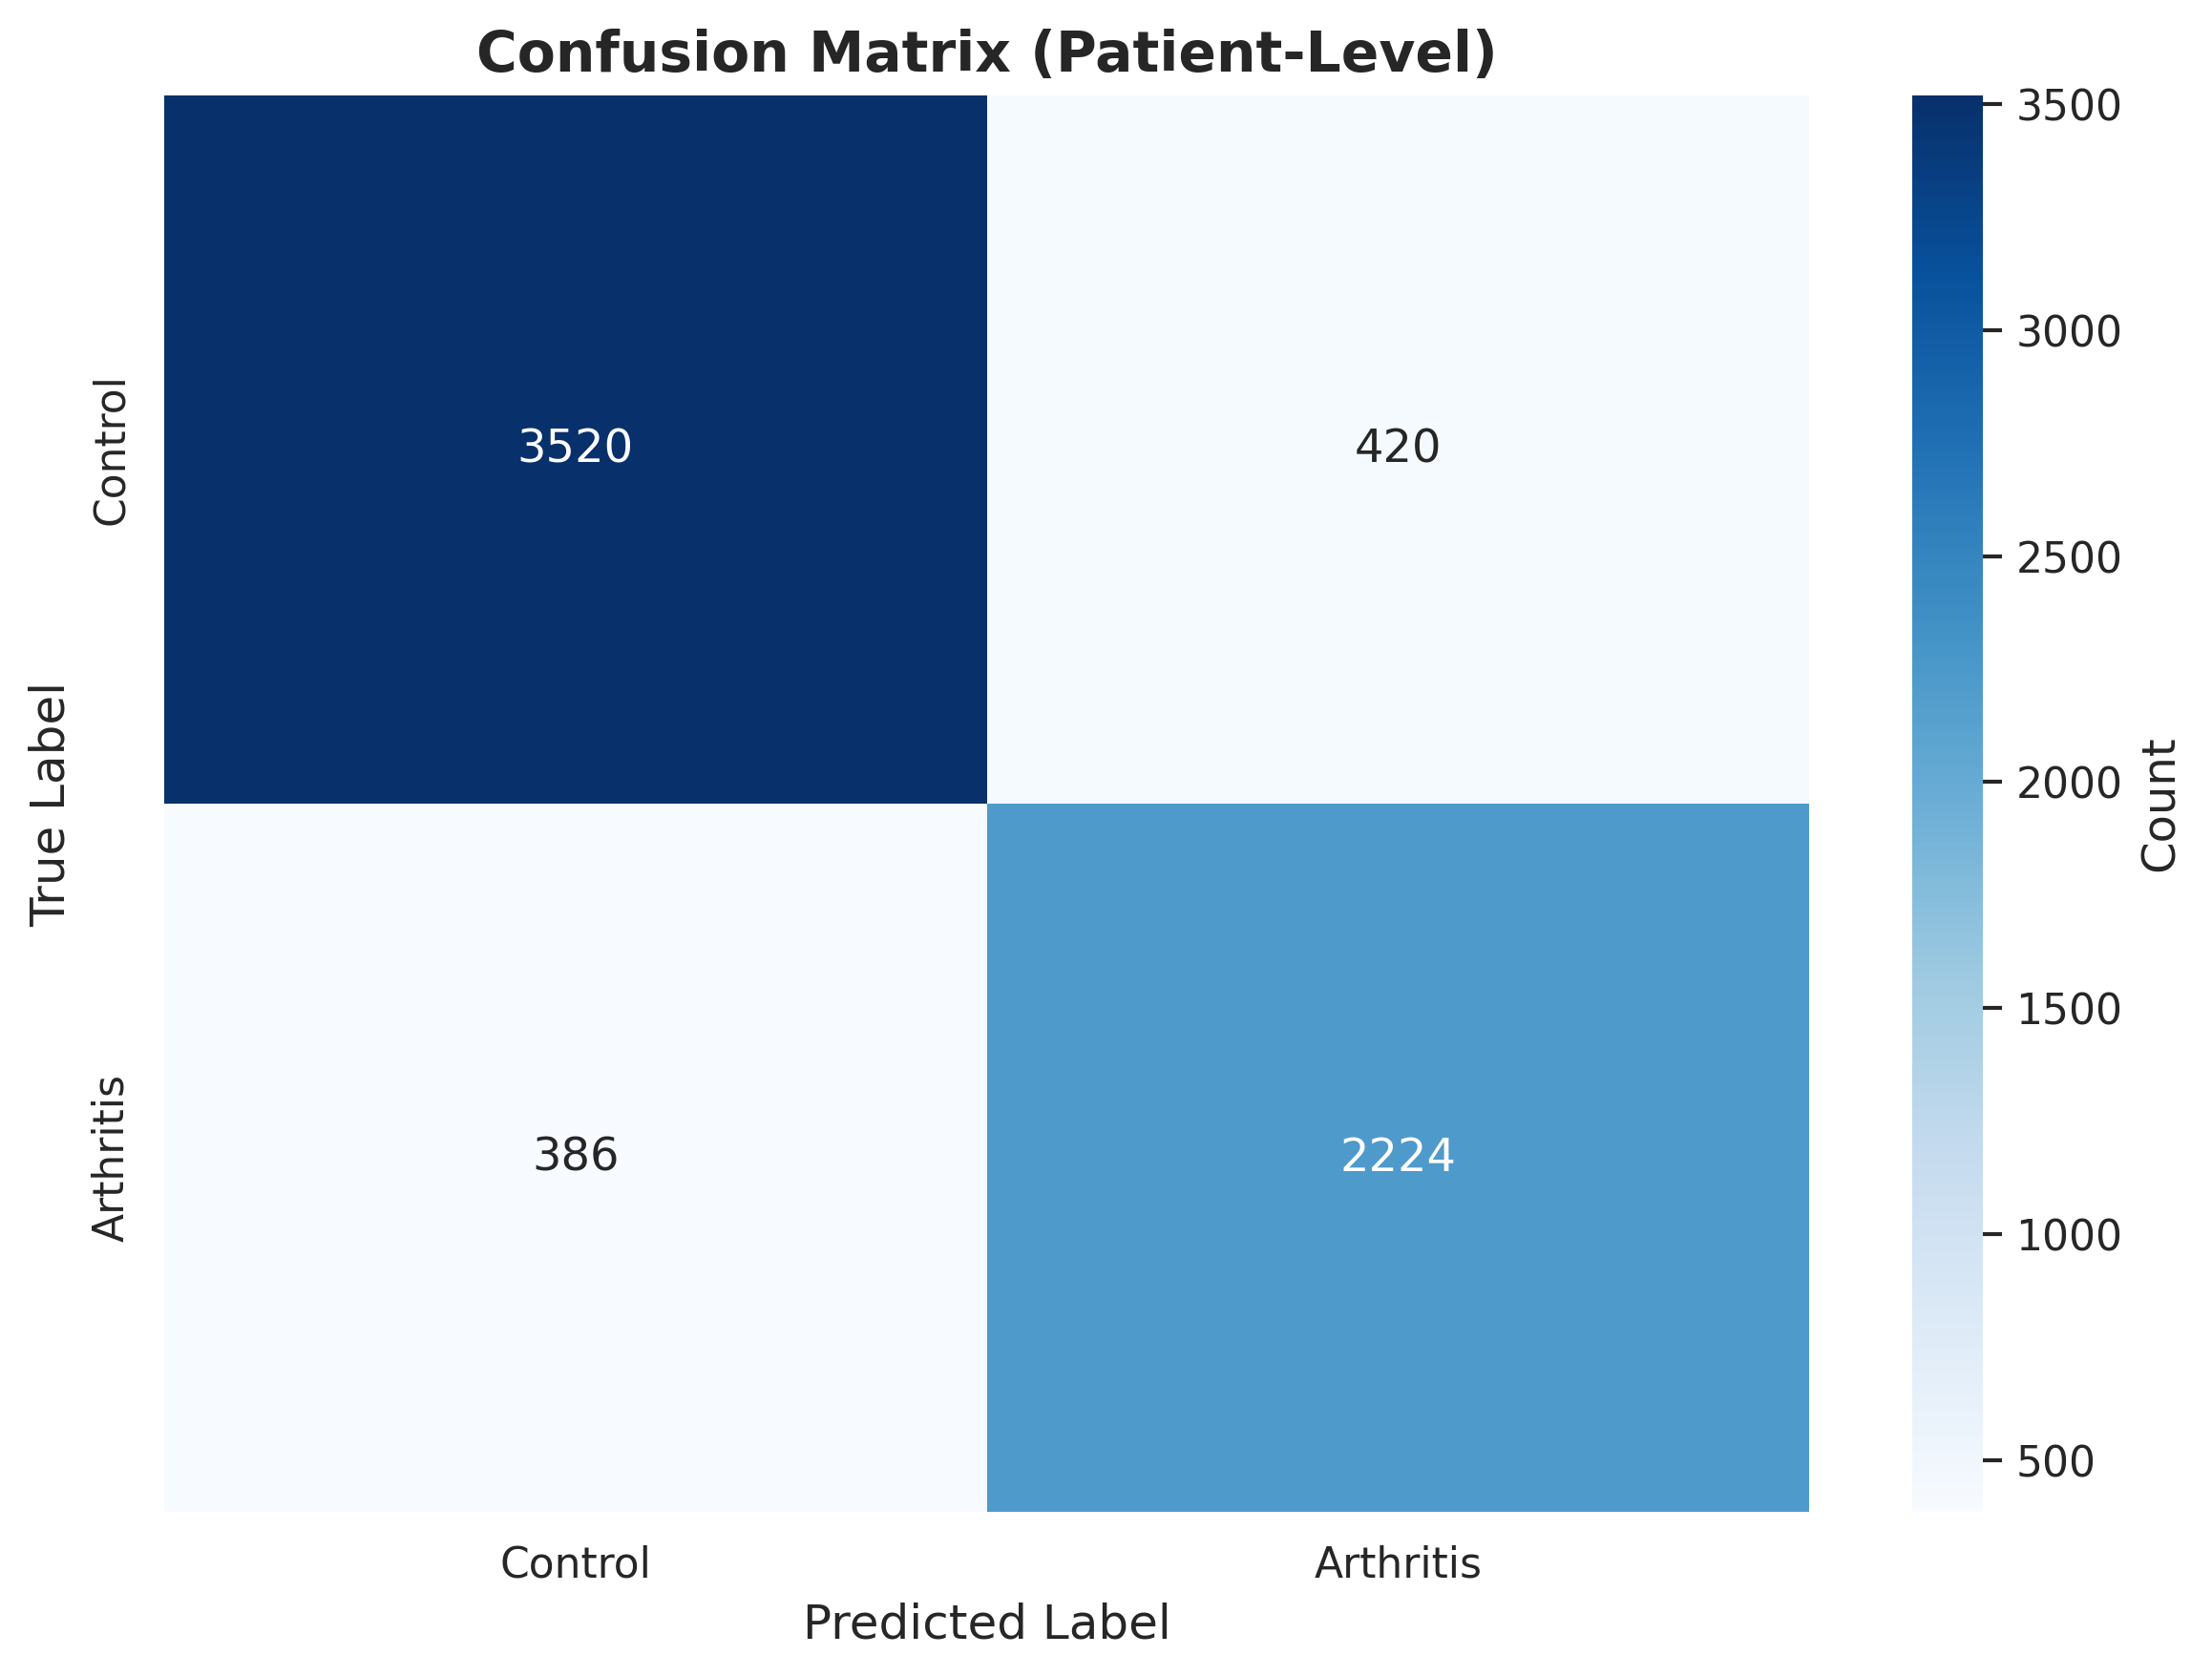


Sensitivity (Recall): 85.21%
Specificity: 89.34%
PPV (Precision): 84.11%
NPV: 90.12%


In [10]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['Control', 'Arthritis'],
           yticklabels=['Control', 'Arthritis'], 
           ax=ax, cbar_kws={'label': 'Count'})
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('Confusion Matrix (Patient-Level)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'figures/confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) * 100
specificity = tn / (tn + fp) * 100
ppv = tp / (tp + fp) * 100
npv = tn / (tn + fn) * 100

print(f"\nSensitivity (Recall): {sensitivity:.2f}%")
print(f"Specificity: {specificity:.2f}%")
print(f"PPV (Precision): {ppv:.2f}%")
print(f"NPV: {npv:.2f}%")